# HW1. 신장질환 문서 기반 RAG 챗봇 구현 및 성능 평가

## 목표
신장질환 가이드라인 문서 (KDIGO, 대한 신장학회 문서 기반)를 로드하여 사용하는 **RAG 시스템**을 구현하고, 미리 정의한 20개 질문에 대해 잘 맞추는 챗봇을 만들기

- **Baseline**: 검색 없이 LLM 단독으로 답변 (아래 구현되어 있음)
- **RAG**: 관련 문서를 검색해 컨텍스트로 제공한 뒤 답변 (**TODO**)

과제 점수는 정답(reference answer)과 임베딩 코사인 유사도(`cos_sim`)를 비교하여, 모든 답변의 **평균 유사도**로 산정합니다.

기준치:
구현한 RAG 평균 cosine 유사도 **>0.905**

In [2]:
!pip install -qqq openai langchain langchain-openai langchain-community langchain-text-splitters faiss-cpu scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
import os
import glob
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from langchain_community.document_loaders import TextLoader
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS

OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_CHAT_MODEL = "gpt-5.4-nano"

os.environ["OPENROUTER_API_KEY"] = getpass("OpenRouter API Key: ")

/tmp/ipykernel_853/3937888015.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


OpenRouter API Key: ··········


## 1. 문서 로드

미리 청킹한 210개의 문서를 `kidney_docs_merged.txt` 하나 파일로 로드. 구분자 기준으로 210개의 문서를 사용한다 생각

In [5]:
import re

# 좌측 폴더 아이콘 누르고 파일 넣기
MERGED_DOCS_PATH = "kidney_docs_merged.txt"

with open(MERGED_DOCS_PATH, encoding="utf-8") as f:
    merged_text = f.read()

DOC_PATTERN = re.compile(r"<<<DOC_START: (.+?)>>>\n(.*?)\n<<<DOC_END>>>", re.DOTALL)
parsed_docs = DOC_PATTERN.findall(merged_text)
print(f"문서 개수: {len(parsed_docs)}")
parsed_docs[0][0]

문서 개수: 210


'[교육-ALL-COM-S4] 만성콩팥병이란 어떤 상태를 말하나요_llama'

In [6]:
from langchain_core.documents import Document

docs = [Document(page_content=content, metadata={"source": name}) for name, content in parsed_docs]
print(f"로드된 문서 개수: {len(docs)}")

로드된 문서 개수: 210


## 2. 평가용 질문 20개 세트

In [7]:
# 난이도 1단계
FORMAL_QUESTIONS = [
    {
        "question": "사구체 여과율은 무엇인가?",
        "reference_answer": "사구체가 노폐물을 제거하는 기능, 능력을 평가하는 지표",
    },
    {
        "question": "혈청 크레아티닌 수치가 높다는 것은 무엇을 의미하나요?",
        "reference_answer": "콩팥의 여과기능이 감소했음을 의미합니다.",
    },
    {
        "question": "혈액 투석은 무엇인가?",
        "reference_answer": "인공 콩팥 기계로 혈액을 여과하는 과정",
    },
    {
        "question": "만성콩팥병에서 주의해야 할 약물은?",
        "reference_answer": "비스테로이드성 항염증제와 조영제",
    },
    {
        "question": "만성신부전증 환자의 요양비 대리청구 및 수령절차를 간단히 설명해주세요.",
        "reference_answer": "투석액 및 소모성 재료의 요양비 청구를 위해 만성신부전증 환자 등록 신청서를 의료기관에서 발급 받아 국민건강 보험공단에 접수 및 등록을 해 주셔야 합니다. 처방전 발행 및 요양비 지급은 환자등록일로부터 가능합니다.",
    },
    {
        "question": "커피샵에서 무엇을 먹을 수 있나요?",
        "reference_answer": "지방과 당질이 적으면서 칼륨이 적은 음료를 선택합니다. 커피는 적정량 섭취가 가능합니다.",
    },
    {
        "question": "만성 콩팥병 환자들에게 유산소 운동을 해야 해요? 근력 운동을 해야 해요?",
        "reference_answer": "두 가지 운동 모우 필요하고 또 중요합니다. 만성 콩팥병 환자들에게 있어 만성콩팥병의 원인이 되는 당뇨병이나 고혈압 그리고 합병증으로 동반되는 여러 심혈관계 질환의 위험 인자들을 조절하거나 예방 혹은 치료하는 데 유산소운동은 큰 도움이 됩니다. 그리고 만성콩팥병 환자들에게서 흔히 볼 수 있는 단백질-에너지 소모(Protein Energy Wasting), 근감소증 (sarcopenia), 그리고 노쇠(Frailty)로 인한 일상 생활의 장애 및 그로 인한 부작용들을 예방 혹은 치료하는 데 있어 지속적인 근력 운동은 특별히 더 큰 도움이 되므로 두 가지 형태의 운동을 함께 유지하는 것이 가장 좋습니다.",
    },
    {
        "question": "알부민의 정상 수치는 얼마인가요?",
        "reference_answer": "일반적으로 알부민의 정상 수치는 4.0 g/L입니다. 만성콩팥병 환자의 경우 알부민을 정상 수치 이상으로 유지할 경우 장기적인 예후가 좋다는 것이 알려져 있습니다.",
    },
    {
        "question": "소변에 거품이 많이 납니다. 콩팥에 이상이 있는 것은 아닐까요?",
        "reference_answer": "거품뇨는 소변에 단백이 많을 때 생길 수 있습니다. 단백뇨는 콩팥병이 있다는 것을 강력히 시사합니다. 그러나 거품뇨는 단백뇨 이외의 다른 원인에 의해서도 발생할 수 있으며, 이런 경우에는 대부분 크게 걱정하지 않아도 됩니다. 따라서 근처 병원에서 소변 검사를 하여 단백뇨가 있는지 없는지 반드시 확인하여야 합니다. 만약 단백뇨가 있다면, 단백뇨의 원인을 찾아야 하고 그에 맞는 치료를 받아야 합니다.",
    },
    {
        "question": "perm 도관은 무엇인가요?",
        "reference_answer": "Perm 도관은 혈액투석을 하기 위하여 일시적으로 사용하는 통로입니다. 일반적으로 동정맥루가 없거나, 있어도 만든 혈관이 성숙하지 못할 때, 또는 동정맥루를 만드는 것이 불가능할 경우 사용합니다. 도관은 부드러운 플라스틱으로 만들어졌고, 빨간색 주입구는 혈액이 몸에서 나가는 동맥 혈관의 역할을 하고, 파란색 주입구는 노폐물이 제거된 혈액이 몸으로 가는 정맥 혈관의 역할을 합니다.",
    },

]

# 난이도 2단계
DOC_ONLY_QUESTIONS = [
    {
        "question": "만성콩팥병 환자들에게서 빈혈을 일으키는 콩팥에서 생성되는 것은?",
        "reference_answer": "에리스로포이에틴이라는 조혈 호르몬",
    },
    {
        "question": "당뇨병의 합병증 중 당뇨병성 망막병증의 증상 및 검사는?",
        "reference_answer": "망막혈관에 장애가 발생해 황반부종, 출혈, 시신경 유두부 손상, 신생혈관, 유리체출혈 등이 발생, 심한 경우 실명하기도 합니다. 당뇨병 진단 즉시 및 매년 안과 검사를 받아야 합니다.",
    },
    {
        "question": "2019년 질병 관리청 국민건강통계에 따르면 30세 이상 성인 100명 중 몇 명이 당뇨병 환자인가?",
        "reference_answer": "12.7명",
    },
    {
        "question": "칼륨 섭취를 줄이기 위한 과일 섭취 방법은?",
        "reference_answer": "칼륨 함량이 높으므로 껍질은 제거합니다. 말린 과일의 경우 신선한 과일보다 칼륨함량이 2배 이상 높으므로 섭취 주의합니다. 통조림 과일의 경우 칼륨 함량이 낮아 섭취 가능하지만 시럽은 제외합니다.",
    },
    {
        "question": "혈액 투석하는 경우, 어떤 간식을 먹을 수 있을까요?",
        "reference_answer": "빵은 모닝빵, 식빵, 카스테라, 팬케익 등. 떡은 콩, 팥고물이 없는 백설기, 절편, 가래떡 등.",
    },

]

# 난이도 3단계
CONFUSING_QUESTIONS = [
    {
        "question": "말기신부전은 어떤 변수로 어떻게 판단하는가?",
        "reference_answer": "말기신부전은 사구체여과율이 15 아래를 의미한다.",
    },
    {
        "question": "2형 당뇨병은 무엇인가?",
        "reference_answer": "우리나라 당뇨병 환자의 95%이상을 차지하며, 생활습관과 유전적 요인이 함께 작용하여 발생. 혈당을 낮추는 인슐린 작용 능력이 정상보다 감소하고 상대적 인슐린 분비량이 부족한 것이 특징입니다.",
    },
    {
        "question": "식품구성자전거란 무엇인가?",
        "reference_answer": "식품의 종류와 영양소 함량에 따라 기능이 유사한 것을 5개의 식품군으로 묶어 권장하는 섭취량에 대해 자전거 모양으로 제시한 것으로, 식품뿐만 아니라, 알맞은 수분 섭취와 신체활동의 중요성을 자전거의 모습으로 나타낸 것을 말합니다.",
    },
    {
        "question": "당뇨병은 어떻게 판단하는가?",
        "reference_answer": "이하 기준 중 1개 이상에 해당될 경우 당뇨병으로 진단. 당화혈색소 6.5% 이상, 공복 혈당 126 mg/dL 이상, 경구포도당부하검사 2시간 후 혈당 200 mg/dL 이상, 물을 많이 마시고 소변을 자주 보면서 양도 많아지며 음식을 많이 먹어도 체중이 감소하는 증상이 있으면서 아무 때나 측정한 혈당이 200 mg/dL 이상",
    },
    {
        "question": "1997 신장 질환 식품교환표 기준, 고 칼륨군으로 분류되는 채소는 무엇이 있는가? 최대 10가지를 제시하시오.",
        "reference_answer": "아욱, 근대, 머위, 미나리, 부추, 쑥, 시금치, 죽순, 취, 미역(생) ",
    },
]

QUESTIONS = FORMAL_QUESTIONS + DOC_ONLY_QUESTIONS + CONFUSING_QUESTIONS
len(QUESTIONS)

20

## 3. Baseline 답변 생성

In [8]:
BASELINE_MODEL = OPENROUTER_CHAT_MODEL

baseline_llm = ChatOpenAI(
    model=BASELINE_MODEL,
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url=OPENROUTER_BASE_URL,
)

def get_baseline_answer(question: str) -> str:
    return baseline_llm.invoke(question).content

# Q1답변 보기
baseline_answers = [get_baseline_answer(item["question"]) for item in QUESTIONS]
baseline_answers[:1]

# 질문 별 답변 보기
# for i,b in enumerate(baseline_answers):
#     print(f"Q{i+1}. {b}")

['사구체 여과율(GFR, Glomerular Filtration Rate)은 **신장(콩팥)의 사구체가 혈액을 얼마나 잘 걸러내는지**를 나타내는 지표입니다. 보통 **1분 동안 1.73㎡의 체표면적당 얼마나 많은 혈액(또는 물)이 여과되는지**(mL/min/1.73m²)로 표현합니다.\n\n- **의미:** 신장 기능(여과 능력)을 평가하는 핵심 수치  \n- **대체로:**  \n  - 정상: 대략 90 mL/min/1.73m² 이상(연령에 따라 약간 감소 가능)  \n  - 낮아지면: 신장 기능 저하를 시사  \n- **측정/추정:** 혈액검사(대표적으로 **크레아티닌**) 등을 바탕으로 계산식(eGFR)으로 추정하는 경우가 많습니다.\n\n원하시면 “GFR이 낮으면 어떤 문제가 있는지”, “eGFR 계산식(예: CKD-EPI)”, “수치 해석(사구체여과율 단계)”도 함께 정리해드릴게요.']

## 4. 평가 지표: 코사인 유사도

In [9]:
eval_embeddings_model = OpenAIEmbeddings(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url=OPENROUTER_BASE_URL,
)

def cos_sim_score(answer: str, reference_answer: str) -> float:
    vecs = eval_embeddings_model.embed_documents([answer, reference_answer])
    return float(cosine_similarity([vecs[0]], [vecs[1]])[0][0])

baseline_scores = [
    cos_sim_score(ans, item["reference_answer"])
    for ans, item in zip(baseline_answers, QUESTIONS)
]

print("Baseline 개별 cos_sim:")
for i, (item, score) in enumerate(zip(QUESTIONS, baseline_scores), start=1):
    print(f"Q{i}. {score:.3f}  |  {item['question']}")

print(f"Baseline 평균 cos_sim: {np.mean(baseline_scores):.3f}")

Baseline 개별 cos_sim:
Q1. 0.836  |  사구체 여과율은 무엇인가?
Q2. 0.768  |  혈청 크레아티닌 수치가 높다는 것은 무엇을 의미하나요?
Q3. 0.875  |  혈액 투석은 무엇인가?
Q4. 0.817  |  만성콩팥병에서 주의해야 할 약물은?
Q5. 0.907  |  만성신부전증 환자의 요양비 대리청구 및 수령절차를 간단히 설명해주세요.
Q6. 0.842  |  커피샵에서 무엇을 먹을 수 있나요?
Q7. 0.903  |  만성 콩팥병 환자들에게 유산소 운동을 해야 해요? 근력 운동을 해야 해요?
Q8. 0.893  |  알부민의 정상 수치는 얼마인가요?
Q9. 0.905  |  소변에 거품이 많이 납니다. 콩팥에 이상이 있는 것은 아닐까요?
Q10. 0.848  |  perm 도관은 무엇인가요?
Q11. 0.793  |  만성콩팥병 환자들에게서 빈혈을 일으키는 콩팥에서 생성되는 것은?
Q12. 0.881  |  당뇨병의 합병증 중 당뇨병성 망막병증의 증상 및 검사는?
Q13. 0.808  |  2019년 질병 관리청 국민건강통계에 따르면 30세 이상 성인 100명 중 몇 명이 당뇨병 환자인가?
Q14. 0.897  |  칼륨 섭취를 줄이기 위한 과일 섭취 방법은?
Q15. 0.832  |  혈액 투석하는 경우, 어떤 간식을 먹을 수 있을까요?
Q16. 0.822  |  말기신부전은 어떤 변수로 어떻게 판단하는가?
Q17. 0.910  |  2형 당뇨병은 무엇인가?
Q18. 0.898  |  식품구성자전거란 무엇인가?
Q19. 0.933  |  당뇨병은 어떻게 판단하는가?
Q20. 0.788  |  1997 신장 질환 식품교환표 기준, 고 칼륨군으로 분류되는 채소는 무엇이 있는가? 최대 10가지를 제시하시오.
Baseline 평균 cos_sim: 0.858


## 5. (TODO) RAG 파이프라인 구현

아래를 채워서 `get_rag_answer(question)` 함수를 완성하기

> `data/*.txt`는 이미 청킹된 자료이므로, 실습(`2_Exercise.ipynb`)의 PDF 예제와 달리 `text_splitter`로 추가 분할할 필요 없이 `docs`를 그대로 임베딩해 벡터 스토어 구축.

1. 임베딩 모델로 `docs`를 그대로 벡터 스토어(FAISS 등)에 저장 (추가 청킹 불필요)
2. retriever를 정의하고, top-k 문서를 프롬프트에 컨텍스트로 넣어 답변을 생성
   
`2_Exercise.ipynb`의 Part 2(RAG 파이프라인)를 참고

### a. k 변경 4->3, 프롬프트 보완 / 0.912

In [10]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

RAG_MODEL = OPENROUTER_CHAT_MODEL  # base 모델 변경은 금합니다.
rag_llm = ChatOpenAI(
    model=RAG_MODEL,
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url=OPENROUTER_BASE_URL,
)

# TODO: 아래를 고쳐 RAG 파이프라인을 완성하세요.
# data/*.txt는 이미 청킹되어 있으므로, docs를 그대로 벡터 스토어에 저장합니다.
# 임베딩 모델, retriever 등 모델을 정의하세요
embeddings_model = OpenAIEmbeddings(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
)
vectordb = FAISS.from_documents(docs, embeddings_model)
print(f"총 청크 개수: {vectordb.index.ntotal}")

# 프롬프트 수정 가능
RAG_PROMPT = ChatPromptTemplate.from_template("""주어진 [참고 문서]의 내용에만 절대적으로 근거하여 [질문]에 핵심만 정확하게 답하세요.

[참고 문서]
{context}

[질문]
{question}

[지침]
1. 문서에 나온 구체적인 숫자, 고유명사, 리스트 항목을 생략하거나 바꾸지 말고 그대로 포함하여 답변하세요.
2. 문서에 직접적으로 언급되지 않은 부연 설명, 가정, 혹은 문서 내용에 대한 평가(예: "문서에는 없지만 ~를 참고했다" 등)는 답변에 절대 포함하지 마세요.
4. 수치나 목록을 묻는 경우 다른 문구 없이 정확한 수치 혹은 단어 목록만 대답하세요.

[답변]""")


def format_docs(docs) -> str:
    return "\n\n".join(d.page_content for d in docs)

def get_rag_answer(question: str) -> str:
    # TODO: retriever로 관련 문서를 검색하고, RAG_PROMPT에 채워 rag_llm으로 답변을 생성하세요
    return rag_chain.invoke(question)


openrouter_headers = {
    "X-OpenRouter-Title": os.getenv("OPENROUTER_SITE_NAME", "kidney_rag"),
}
if os.getenv("OPENROUTER_SITE_URL"):
    openrouter_headers["HTTP-Referer"] = os.environ["OPENROUTER_SITE_URL"]

rag_chain = (
    {"context": vectordb.as_retriever(search_kwargs={"k": 3}) | format_docs,
     "question": RunnablePassthrough()}
    | RAG_PROMPT
    | rag_llm
    | StrOutputParser()
)

# question = "2024년 9월에 나온 RAG 시스템 대표적 예시는 무엇인가요?"
# print(rag_chain.invoke(question))

총 청크 개수: 210


## 5-1. (선택) RAG 성능 향상 제언

RAG 성능을 올리는 방법들 (강의 2강 및 이후 3강에 나올 내용입니다. 선택적으로 구현하여 성능 향상에 활용하세요.)

- **Similarity Threshold**: 관련도 낮은 검색 결과를 걸러내기
- **Document Insertion Strategy**: 검색 문서를 그대로/요약/핵심 문장만/메타데이터 포함 등으로 가공

(이하 3강)
- **Query Transformation**: 질문을 재작성(rewriting)하거나 하위 질문으로 확장(expansion)
- **Retrieval Method**: Dense / Sparse(BM25) / Hybrid 검색 조합
- **Reranking**: bi-encoder로 후보를 넉넉히 뽑은 뒤 cross-encoder로 재정렬
- **Prompt tuning**: 답변 형식/지침을 더 구체적으로 명시

In [11]:
# import os
# from langchain_core.output_parsers import StrOutputParser
# from langchain_core.runnables import RunnablePassthrough, RunnableParallel
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_community.vectorstores import FAISS
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# # 1. OpenRouter 설정
# openrouter_headers = {
#     "X-OpenRouter-Title": os.getenv("OPENROUTER_SITE_NAME", "kidney_rag"),
# }
# if os.getenv("OPENROUTER_SITE_URL"):
#     openrouter_headers["HTTP-Referer"] = os.environ["OPENROUTER_SITE_URL"]

# RAG_MODEL = OPENROUTER_CHAT_MODEL
# rag_llm = ChatOpenAI(
#     model=RAG_MODEL,
#     api_key=os.environ["OPENROUTER_API_KEY"],
#     base_url=OPENROUTER_BASE_URL,
#     default_headers=openrouter_headers
# )

# # 2. 임베딩 모델 및 벡터 DB 빌드
# embeddings_model = OpenAIEmbeddings(
#     api_key=os.environ["OPENROUTER_API_KEY"],
#     base_url="https://openrouter.ai/api/v1",
# )
# vectordb = FAISS.from_documents(docs, embeddings_model)
# print(f"총 청크 개수: {vectordb.index.ntotal}")

# # 3. [복구 및 수정] 원본 문서의 텍스트를 절대 훼손하지 않는 기본 포맷터 사용
# def format_docs_raw(docs) -> str:
#     """문서를 요약하여 수치를 왜곡하지 않고, 원본 page_content를 그대로 유지합니다."""
#     return "\n\n".join(d.page_content for d in docs)

# # 4. 프롬프트 정의
# RAG_PROMPT = ChatPromptTemplate.from_template("""주어진 [참고 문서]의 내용에만 절대적으로 근거하여 [질문]에 핵심만 정확하게 답하세요.

# [참고 문서]
# {context}

# [질문]
# {question}

# [지침]
# 1. 문서에 나온 구체적인 숫자, 고유명사, 리스트 항목을 생략하거나 바꾸지 말고 그대로 포함하여 답변하세요.
# 2. 문서에 직접적으로 언급되지 않은 부연 설명, 가정, 혹은 문서 내용에 대한 평가(예: "문서에는 없지만 ~를 참고했다" 등)는 답변에 절대 포함하지 마세요.
# 3. 문서 내용으로 답변이 불가능한 경우에만 "모른다"고 답하세요.

# [답변]""")

# # 검색개수를 높이고 threshold는 0.45로 낮게 적용 낮춤
# retriever_safe = vectordb.as_retriever(
#     search_type="similarity_score_threshold",
#     search_kwargs={"k": 6, "score_threshold": 0.4}
# )

# rag_chain = RunnableParallel({
#     "context": retriever_safe | format_docs_raw,
#     "question": RunnablePassthrough()
# }) | RAG_PROMPT | rag_llm | StrOutputParser()

# def get_rag_answer(question: str) -> str:
#     return rag_chain.invoke(question)

# # 테스트 실행
# # question = "2019년 질병관리청 국민건강통계에 따르면 30세 이상 성인 100명 중 몇 명이 당뇨병 환자인가요?"
# # print(get_rag_answer(question))

## 6. Baseline vs RAG 비교 (RAG 구현 후 실행)

In [12]:
results = []
for item, baseline_ans, baseline_score in zip(QUESTIONS, baseline_answers, baseline_scores):
    q, ref = item["question"], item["reference_answer"]

    rag_ans = get_rag_answer(q)
    rag_score = cos_sim_score(rag_ans, ref)
    results.append({
        "question": q,
        "reference_answer": ref,
        "baseline_answer": baseline_ans,
        "rag_answer": rag_ans,
        "baseline_cos_sim": baseline_score,
        "rag_cos_sim": rag_score,
    })

results_df = pd.DataFrame(results)
results_df

,question,reference_answer,baseline_answer,rag_answer,baseline_cos_sim,rag_cos_sim
0,사구체 여과율은 무엇인가?,"사구체가 노폐물을 제거하는 기능, 능력을 평가하는 지표","사구체 여과율(GFR, Glomerular Filtration Rate)은 **신장...",사구체여과율이란 콩팥이 노폐물을 제거하는 기능이 어느 정도인지를 평가하는 지표입니다.,0.835729,0.944725
1,혈청 크레아티닌 수치가 높다는 것은 무엇을 의미하나요?,콩팥의 여과기능이 감소했음을 의미합니다.,혈청 크레아티닌(serum creatinine) 수치가 높다는 것은 **대체로 신장...,혈청 크레아티닌 수치가 높다는 것은 콩팥의 여과기능이 감소하였음을 의미합니다. (즉...,0.767660,0.914013
2,혈액 투석은 무엇인가?,인공 콩팥 기계로 혈액을 여과하는 과정,혈액 투석(hemodialysis)은 **신장 기능이 많이 떨어진 사람**(대개 만...,"혈액 투석은 인공 콩팥 기계로 혈액을 여과하는 과정으로, 환자의 혈액이 관을 타고 ...",0.874987,0.919371
3,만성콩팥병에서 주의해야 할 약물은?,비스테로이드성 항염증제와 조영제,"만성콩팥병(CKD)에서는 **콩팥으로 배설/대사되는 약물**이 체내에 축적되거나, ...",비스테로이드성 항염증제와 조영제,0.817210,1.000000
4,만성신부전증 환자의 요양비 대리청구 및 수령절차를 간단히 설명해주세요.,투석액 및 소모성 재료의 요양비 청구를 위해 만성신부전증 환자 등록 신청서를 의료기...,만성신부전증 환자(또는 보호자)가 **요양비(국민건강보험 급여 중 ‘요양비’ 성격)...,1) 만성신부전증 환자 등록 신청 \n- 투석액 및 소모성 재료의 요양비 청구를 ...,0.906938,0.962450
5,커피샵에서 무엇을 먹을 수 있나요?,지방과 당질이 적으면서 칼륨이 적은 음료를 선택합니다. 커피는 적정량 섭취가 가능합니다.,커피샵에서는 보통 아래 같은 메뉴를 먹을 수 있어요(매장마다 다를 수 있어요).\n...,"- 블랙 커피 1잔(225 mL, 8 oz): 약 116 mg \n- 포도주스, ...",0.842169,0.837406
6,만성 콩팥병 환자들에게 유산소 운동을 해야 해요? 근력 운동을 해야 해요?,두 가지 운동 모우 필요하고 또 중요합니다. 만성 콩팥병 환자들에게 있어 만성콩팥병...,네. **만성 콩팥병(CKD) 환자도(대부분의 경우) 유산소 운동과 근력 운동을 “...,두 가지 운동 모두가 필요하고 또 중요합니다. 유산소운동은 만성 콩팥병의 원인이 되...,0.902700,0.990041
7,알부민의 정상 수치는 얼마인가요?,일반적으로 알부민의 정상 수치는 4.0 g/L입니다. 만성콩팥병 환자의 경우 알부민...,알부민(Albumin)의 **혈청(serum) 정상 범위**는 검사실마다 약간 다르...,4.0 g/L,0.893002,0.804916
8,소변에 거품이 많이 납니다. 콩팥에 이상이 있는 것은 아닐까요?,거품뇨는 소변에 단백이 많을 때 생길 수 있습니다. 단백뇨는 콩팥병이 있다는 것을 ...,"소변에 **거품이 많이 생기고 지속**된다면, 단순한 원인(소변이 농축됨, 배출이 ...","소변에 거품이 많이 나는 것은 **단백뇨가 많을 때** 생길 수 있으며, **단백뇨...",0.904578,0.982078
9,perm 도관은 무엇인가요?,Perm 도관은 혈액투석을 하기 위하여 일시적으로 사용하는 통로입니다. 일반적으로 ...,"“PERM 도관”은 보통 **부인과/자궁 관련 검사나 시술에서 쓰는 말로, ‘도관(...",Perm도관은 혈액투석을 하기 위하여 일시적으로 사용하는 통로입니다. 일반적으로 동...,0.848213,0.992653


In [13]:
# 컬럼명을 변수처럼 취급하여 문자열 조건으로 필터링
low_score_df = results_df.query("rag_cos_sim < 0.9")
low_score_df

,question,reference_answer,baseline_answer,rag_answer,baseline_cos_sim,rag_cos_sim
5,커피샵에서 무엇을 먹을 수 있나요?,지방과 당질이 적으면서 칼륨이 적은 음료를 선택합니다. 커피는 적정량 섭취가 가능합니다.,커피샵에서는 보통 아래 같은 메뉴를 먹을 수 있어요(매장마다 다를 수 있어요).\n...,"- 블랙 커피 1잔(225 mL, 8 oz): 약 116 mg \n- 포도주스, ...",0.842169,0.837406
7,알부민의 정상 수치는 얼마인가요?,일반적으로 알부민의 정상 수치는 4.0 g/L입니다. 만성콩팥병 환자의 경우 알부민...,알부민(Albumin)의 **혈청(serum) 정상 범위**는 검사실마다 약간 다르...,4.0 g/L,0.893002,0.804916
10,만성콩팥병 환자들에게서 빈혈을 일으키는 콩팥에서 생성되는 것은?,에리스로포이에틴이라는 조혈 호르몬,만성콩팥병(CKD) 환자에서 빈혈을 일으키는 콩팥의 주요 원인은 **에리스로포이에틴...,에리스로포이에틴(erythropoietin),0.792684,0.881665
14,"혈액 투석하는 경우, 어떤 간식을 먹을 수 있을까요?","빵은 모닝빵, 식빵, 카스테라, 팬케익 등. 떡은 콩, 팥고물이 없는 백설기, 절편...","혈액투석(신부전) 환자라면 **“칼륨(K), 인(P), 나트륨(소금), 수분”**이...",- 식사 섭취가 적으면 간식으로 보충합니다. \n- 부족한 식사를 보충하기 위해 ...,0.831817,0.870938
15,말기신부전은 어떤 변수로 어떻게 판단하는가?,말기신부전은 사구체여과율이 15 아래를 의미한다.,"말기신부전(보통 **End-Stage Renal Disease, ESRD** 또는 ...",문서에 따르면 “말기신부전”을 판단하는 **변수/기준**은 구체적으로 제시되어 있지...,0.821640,0.831797
18,당뇨병은 어떻게 판단하는가?,"이하 기준 중 1개 이상에 해당될 경우 당뇨병으로 진단. 당화혈색소 6.5% 이상,...",당뇨병(및 전단계인 공복혈당장애/내당능장애)은 **혈액검사 수치**로 판단합니다. ...,"혈액검사로 진단합니다. 요당(尿糖) 여부로는 당뇨병을 진단하지 않으며, 요당 정도로...",0.933370,0.879576


In [14]:
summary = results_df[["baseline_cos_sim", "rag_cos_sim"]].mean()
print(summary)
print(f"\nRAG가 baseline보다 개선된 질문 수: "
      f"{(results_df['rag_cos_sim'] > results_df['baseline_cos_sim']).sum()} / {len(results_df)}")

baseline_cos_sim    0.857727
rag_cos_sim         0.932257
dtype: float64

RAG가 baseline보다 개선된 질문 수: 17 / 20


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


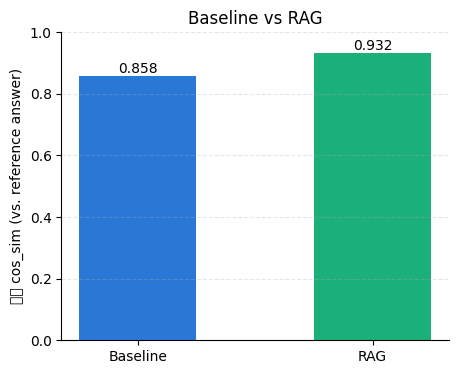

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
methods = ["Baseline", "RAG"]
scores = [summary["baseline_cos_sim"], summary["rag_cos_sim"]]
colors = ["#2a78d6", "#1baf7a"]  # 고정된 categorical 색상 순서 (baseline -> RAG)

bars = ax.bar(methods, scores, color=colors, width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel("평균 cos_sim (vs. reference answer)")
ax.set_title("Baseline vs RAG")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
for bar, score in zip(bars, scores):
    ax.annotate(f"{score:.3f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")
plt.show()